In [2]:
from data_loader import load_data
from filter_utils import filter_top_functions
from timeseries_builder import build_timeseries

In [3]:
df = load_data()
print(f"Data loaded with shape: {df.shape}")

df_top = filter_top_functions(df)
print(f"Filtered top functions: {df_top.shape}")

ts_wide = build_timeseries(df_top)
print(f"Built time series: {ts_wide.shape}")

Data loaded with shape: (1980951, 6)
Filtered top functions: (861398, 6)
Built time series: (4029, 11)


In [4]:
## select only the timeseries i want
ts_only = ts_wide["c8c43e_653cdb"]

In [5]:
ts_only

datetime
1970-01-01 00:00:00    1.0
1970-01-01 00:05:00    0.0
1970-01-01 00:10:00    0.0
1970-01-01 00:15:00    0.0
1970-01-01 00:20:00    0.0
                      ... 
1970-01-14 23:35:00    1.0
1970-01-14 23:40:00    1.0
1970-01-14 23:45:00    1.0
1970-01-14 23:50:00    0.0
1970-01-14 23:55:00    0.0
Name: c8c43e_653cdb, Length: 4029, dtype: float64

In [5]:
ts_only_test = ts_only["1970-01-11":]
ts_only_test

datetime
1970-01-11 00:00:00    5.0
1970-01-11 00:05:00    0.0
1970-01-11 00:10:00    0.0
1970-01-11 00:15:00    0.0
1970-01-11 00:20:00    0.0
                      ... 
1970-01-14 23:35:00    1.0
1970-01-14 23:40:00    1.0
1970-01-14 23:45:00    1.0
1970-01-14 23:50:00    0.0
1970-01-14 23:55:00    0.0
Name: c8c43e_653cdb, Length: 1149, dtype: float64

In [6]:
ts_only_test.to_csv("timeseries_test.csv")

## Bucketized

Bucket 1: 0.0000 → 4.7500
Bucket 2: 4.7500 → 9.5000
Bucket 3: 9.5000 → 14.2500
Bucket 4: 14.2500 → 19.0000
bucket
1    1038
2      87
3      21
4       3
Name: count, dtype: int64


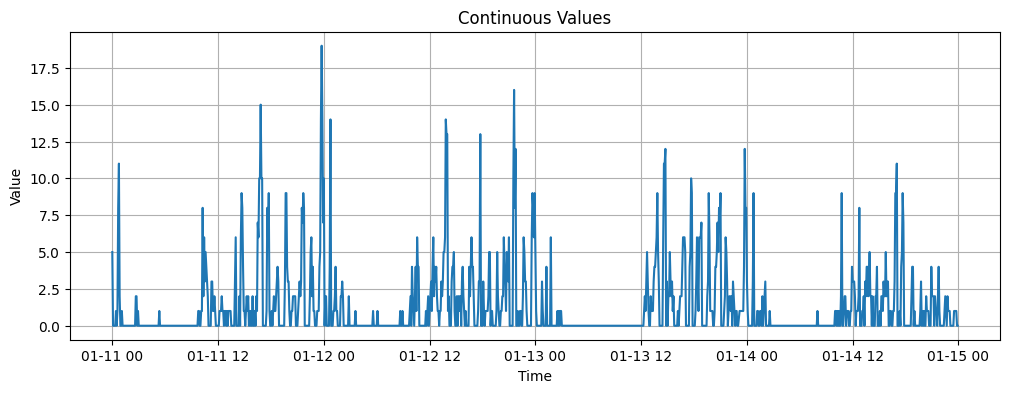

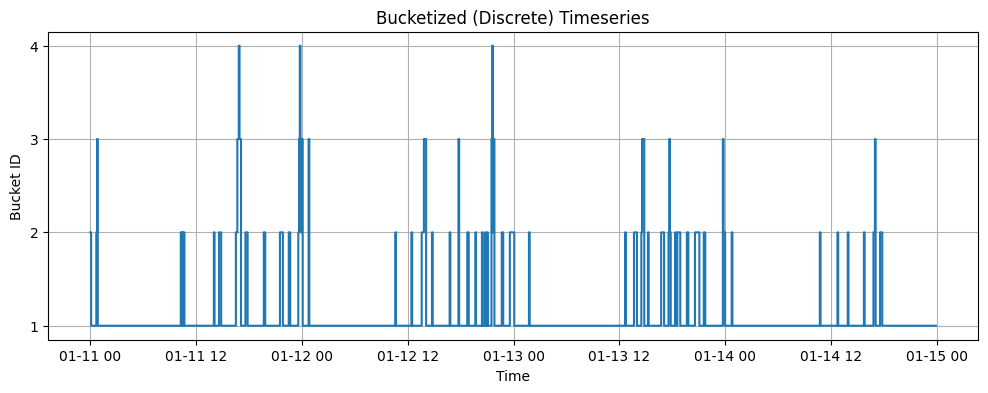

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------------------
# 1. Load & bucketize (same code as before)
# ----------------------------------------
df = pd.read_csv("timeseries_test.csv", parse_dates=["datetime"])
df = df.sort_values("datetime")

num_buckets = 4
value_col = "c8c43e_653cdb"

vmin = df[value_col].min()
vmax = df[value_col].max()
bucket_edges = np.linspace(vmin, vmax, num_buckets + 1)
for i in range(len(bucket_edges) - 1):
    print(f"Bucket {i+1}: {bucket_edges[i]:.4f} → {bucket_edges[i+1]:.4f}")

df["bucket"] = pd.cut(
    df[value_col],
    bins=bucket_edges,
    labels=range(1, num_buckets + 1),
    include_lowest=True
).astype(int)

bucket_counts = df["bucket"].value_counts().sort_index()
print(bucket_counts)

# ----------------------------------------
# 2. Plot continuous series
# ----------------------------------------
plt.figure(figsize=(12, 4))
plt.plot(df["datetime"], df[value_col])
plt.title("Continuous Values")
plt.xlabel("Time")
plt.ylabel("Value")
plt.grid(True)
plt.show()

# ----------------------------------------
# 3. Plot bucketized/discrete series
# ----------------------------------------
plt.figure(figsize=(12, 4))
plt.step(df["datetime"], df["bucket"], where="post")
plt.title("Bucketized (Discrete) Timeseries")
plt.xlabel("Time")
plt.ylabel("Bucket ID")
plt.yticks(range(1, num_buckets + 1))
plt.grid(True)
plt.show()


bucketized_df = df[["datetime", "bucket"]]
bucketized_df.to_csv("timeseries_bucketized.csv", index=False)

In [12]:
!pip install "numpy<2.0" --upgrade
!pip install torch==2.4.1 torchvision==0.19.1 torchaudio==2.4.1
!pip install pytorch-lightning==2.3.0 torchmetrics==1.4.0 transformers==4.44.2 accelerate==0.33.0
!pip install darts==0.30.0 prophet==1.1.5 scikit-learn pandas matplotlib





[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 797.1/797.1 MB 60.5 MB/s  0:00:09m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 16.8 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 13.2 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 91.8 MB/s  0:00:03m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 123.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 123.4 MB/s  0:00:00m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 58.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 129.8 MB/s  0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 129.6 MB/s  0:00:00m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 120.6 MB/s  0:00:010:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━

In [7]:
from darts.models import NHiTSModel, PatchTSTModel
print("✅ Darts models imported successfully!")


ImportError: cannot import name 'PatchTSTModel' from 'darts.models' (/home/giannis.roumpos/virtual/lib/python3.11/site-packages/darts/models/__init__.py)

In [12]:
!pip install prophet cmdstanpy --upgrade


  Using cached prophet-1.2.1-py3-none-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (3.5 kB)
Using cached prophet-1.2.1-py3-none-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (12.1 MB)
  Attempting uninstall: prophet
    Found existing installation: prophet 1.1.5
    Uninstalling prophet-1.1.5:
      Successfully uninstalled prophet-1.1.5

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [4]:
# ======================================================
# 📘 Time Series Benchmarking
# Models: RF, GBDT, Linear, Prophet, N-HiTS, PatchTST
# Data: ts_only (datetime index, single column)
# Deep models via: NeuralForecast (Nixtla)
# ======================================================

import pandas as pd
import numpy as np
import time
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from prophet import Prophet
from neuralforecast import NeuralForecast
from neuralforecast.models.nhits import NHITS
from neuralforecast.models.patchtst import PatchTST
from neuralforecast.utils import AirPassengersDF
import matplotlib.pyplot as plt

# Ensure ts_only is a proper DataFrame
if isinstance(ts_only, pd.Series):
    ts_only = ts_only.to_frame(name='value')

if not isinstance(ts_only.index, pd.DatetimeIndex):
    ts_only.index = pd.to_datetime(ts_only.index)

print(type(ts_only))
print(ts_only.head())

# --- Prepare Data ---
assert isinstance(ts_only, pd.DataFrame), "ts_only must be a pandas DataFrame"
assert ts_only.shape[1] == 1, "ts_only must have one value column"

ts_only = ts_only.sort_index()
points_per_day = 24 * 60 // 5  # 288 samples/day

n_train = 7 * points_per_day
n_val   = 3 * points_per_day
n_test  = 4 * points_per_day

train = ts_only.iloc[:n_train]
val   = ts_only.iloc[n_train:n_train+n_val]
test  = ts_only.iloc[n_train+n_val:]

print(f"Train: {train.shape}, Val: {val.shape}, Test: {test.shape}")

# --- Normalize ---
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train)
val_scaled   = scaler.transform(val)
test_scaled  = scaler.transform(test)

# --- Supervised data for sklearn models ---
def create_lagged_features(data, lags=12):
    X, y = [], []
    for i in range(lags, len(data)):
        X.append(data[i-lags:i])
        y.append(data[i])
    return np.array(X), np.array(y)

lags = 12  # 1 hour of history
X_train, y_train = create_lagged_features(train_scaled)
X_val, y_val = create_lagged_features(np.concatenate([train_scaled[-lags:], val_scaled]))
X_test, y_test = create_lagged_features(np.concatenate([train_scaled[-lags:], val_scaled, test_scaled]))

# Flatten (n_samples, lags, 1) -> (n_samples, lags)
X_train = X_train.reshape(X_train.shape[0], -1)
X_val   = X_val.reshape(X_val.shape[0], -1)
X_test  = X_test.reshape(X_test.shape[0], -1)

results = {}

# def evaluate_model(name, model, X_train, y_train, X_val, y_val):
#     start_train = time.time()
#     model.fit(X_train, y_train.ravel())
#     train_time = time.time() - start_train

#     start_infer = time.time()
#     y_pred = model.predict(X_val)
#     infer_time = time.time() - start_infer

#     mae = mean_absolute_error(y_val, y_pred)
#     results[name] = {'MAE': mae, 'train_time': train_time, 'infer_time': infer_time}
#     print(f"{name}: MAE={mae:.4f}, train={train_time:.2f}s, infer={infer_time:.2f}s")
def evaluate_model(name, model, X_train, y_train, X_val, y_val, scaler):
    start_train = time.time()
    model.fit(X_train, y_train.ravel())
    train_time = time.time() - start_train

    start_infer = time.time()
    y_pred = model.predict(X_val)
    infer_time = time.time() - start_infer

    # --- Inverse-transform to original scale ---
    y_true_inv = scaler.inverse_transform(y_val.reshape(-1, 1)).ravel()
    y_pred_inv = scaler.inverse_transform(y_pred.reshape(-1, 1)).ravel()

    mae = mean_absolute_error(y_true_inv, y_pred_inv)
    results[name] = {'MAE': mae, 'train_time': train_time, 'infer_time': infer_time}

    print(f"{name}: MAE={mae:.4f}, train={train_time:.2f}s, infer={infer_time:.2f}s")

    return y_pred_inv, y_true_inv


# --- Classical ML Models ---
rf_y_pred_inv, rf_y_true_inv = evaluate_model("RandomForest", RandomForestRegressor(n_estimators=200, random_state=42),
               X_train, y_train, X_val, y_val, scaler)
gbdt_y_pred_inv, gbdt_y_true_inv = evaluate_model("GBDT", GradientBoostingRegressor(random_state=42),
               X_train, y_train, X_val, y_val, scaler)
lr_y_pred_inv, lr_y_true_inv = evaluate_model("LinearRegression", LinearRegression(),
               X_train, y_train, X_val, y_val, scaler)

# --- Prophet ---
train_prophet = train.reset_index().rename(columns={train.columns[0]: 'y', 'datetime': 'ds'})
val_prophet   = val.reset_index().rename(columns={val.columns[0]: 'y', 'datetime': 'ds'})

start_train = time.time()
prophet_model = Prophet(stan_backend='CMDSTANPY')
prophet_model.fit(train_prophet)
train_time = time.time() - start_train

start_infer = time.time()
forecast = prophet_model.predict(val_prophet)
infer_time = time.time() - start_infer

mae = mean_absolute_error(val_prophet['y'], forecast['yhat'])
results["Prophet"] = {'MAE': mae, 'train_time': train_time, 'infer_time': infer_time}
print(f"Prophet: MAE={mae:.4f}, train={train_time:.2f}s, infer={infer_time:.2f}s")

# --- NeuralForecast Deep Models (N-HiTS, PatchTST) ---
# NeuralForecast expects a df with columns: ['unique_id', 'ds', 'y']
df_nf = ts_only.reset_index().rename(columns={'datetime': 'ds', ts_only.columns[0]: 'y'})
df_nf['unique_id'] = 'series_1'  # single time series

# Train/Val/Test split indices
train_end = df_nf.index[n_train]
val_end = df_nf.index[n_train + n_val]

# Define models
models = [
    NHITS(input_size=lags, h=1, max_steps=50),
    PatchTST(input_size=lags, h=1, max_steps=50)
]

horizon = len(val)

for model in models:
    name = model.__class__.__name__
    start_train = time.time()

    # redefine the model with the full horizon
    model = model.__class__(input_size=lags, h=horizon, max_steps=300)
    nf = NeuralForecast(models=[model], freq='5min')
    nf.fit(df=df_nf.iloc[:train_end])

    train_time = time.time() - start_train

    start_infer = time.time()
    forecasts = nf.predict()  # no df arg -> uses internal history
    infer_time = time.time() - start_infer
    # Get forecast column name automatically (e.g., 'NHiTS' or 'PatchTST')
    forecast_col = [c for c in forecasts.columns if c not in ['unique_id', 'ds']][0]

    

    y_true = df_nf.iloc[train_end:train_end + horizon]['y'].values
    # y_pred = forecasts.query("unique_id == 'series_1'")['y_hat'].values
    y_pred = forecasts.query("unique_id == 'series_1'")[forecast_col].values

    if name == "NHiTS":
        nhiits_y_pred = y_pred
    if name == "PatchTST":
        patchtst_y_pred = y_pred
        
    mae = mean_absolute_error(y_true, y_pred)
    results[name] = {'MAE': mae, 'train_time': train_time, 'infer_time': infer_time}
    print(f"{name}: MAE={mae:.4f}, train={train_time:.2f}s, infer={infer_time:.2f}s")

# --- Results Summary ---
results_df = pd.DataFrame(results).T.sort_values("MAE")
print("\n=== Final Results ===")
print(results_df)
results_df.to_csv("timeseries_benchmark_results.csv")




/home/giannis.roumpos/virtual/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/giannis.roumpos/virtual/lib/python3.11/site-packages/lightning_fabric/__init__.py:41: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
2025-11-28 10:38:49,795	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2025-11-28 10:38:49,879	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


<class 'pandas.core.frame.DataFrame'>
                     value
datetime                  
1970-01-01 00:00:00    1.0
1970-01-01 00:05:00    0.0
1970-01-01 00:10:00    0.0
1970-01-01 00:15:00    0.0
1970-01-01 00:20:00    0.0
Train: (2016, 1), Val: (864, 1), Test: (1149, 1)
RandomForest: MAE=1.0973, train=0.76s, infer=0.02s
GBDT: MAE=1.0600, train=0.15s, infer=0.00s
LinearRegression: MAE=1.1165, train=0.00s, infer=0.00s


10:38:51 - cmdstanpy - INFO - Chain [1] start processing
10:38:51 - cmdstanpy - INFO - Chain [1] done processing


Prophet: MAE=1.3336, train=0.20s, infer=0.12s


Seed set to 1
Seed set to 1
Seed set to 1
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA A100-PCIE-40GB') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name         | Type          | Params | Mode 
-------------------------------------------------------
0 | loss         | MAE           | 0      | train
1 | padder_train | ConstantPad1d | 0      | train
2 | scaler       | TemporalNorm  | 0      | train
3 | blocks       | ModuleList    | 3.2 M  | train
-------------------------------------------------------
3.2 M     Trainable params
0         Non-trainable params
3.2 M     Total p

...

Epoch 99: 100%|██████████| 1/1 [00:00<00:00, 92.36it/s, v_num=550, train_loss_step=1.770, train_loss_epoch=1.790] 
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 199: 100%|██████████| 1/1 [00:00<00:00, 97.95it/s, v_num=550, train_loss_step=1.550, train_loss_epoch=1.550] 
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 299: 100%|██████████| 1/1 [00:00<00:00, 97.82it/s, v_num=550, train_loss_step=1.490, train_loss_epoch=1.490] 
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 299: 100%|██████████| 1/1 [00:00<00:00, 56.66it/s, v_num=550, train_loss_step=1.490, train_loss_epoch=1.490]

`Trainer.fit` stopped: `max_steps=300` reached.


Epoch 299: 100%|██████████| 1/1 [00:00<00:00, 52.34it/s, v_num=550, train_loss_step=1.490, train_loss_epoch=1.490]


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 167.18it/s]
PatchTST: MAE=1.7634, train=3.78s, infer=0.08s

=== Final Results ===
                       MAE  train_time  infer_time
GBDT              1.060037    0.148963    0.000950
RandomForest      1.097289    0.755522    0.022915
LinearRegression  1.116506    0.004036    0.004937
Prophet           1.333645    0.197464    0.122673
NHITS             1.571487    4.008718    0.096540
PatchTST          1.763380    3.776334    0.077149


## normalized

In [5]:
# ======================================================
# 📘 Time Series Benchmarking (Normalized + Original Errors)
# Models: RF, GBDT, Linear, Prophet, N-HiTS, PatchTST
# Data: ts_only (datetime index, single column)
# ======================================================

import pandas as pd
import numpy as np
import time
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from prophet import Prophet
from neuralforecast import NeuralForecast
from neuralforecast.models.nhits import NHITS
from neuralforecast.models.patchtst import PatchTST
import matplotlib.pyplot as plt

# ======================================================
# --- Prepare Data ---
# ======================================================

# Ensure ts_only is a DataFrame
if isinstance(ts_only, pd.Series):
    ts_only = ts_only.to_frame(name='value')

if not isinstance(ts_only.index, pd.DatetimeIndex):
    ts_only.index = pd.to_datetime(ts_only.index)

ts_only = ts_only.sort_index()
assert ts_only.shape[1] == 1, "ts_only must have one value column"

print(type(ts_only))
print(ts_only.head())

points_per_day = 24 * 60 // 5  # 288 samples/day

n_train = 7 * points_per_day
n_val   = 3 * points_per_day
n_test  = 4 * points_per_day

train = ts_only.iloc[:n_train]
val   = ts_only.iloc[n_train:n_train+n_val]
test  = ts_only.iloc[n_train+n_val:]

print(f"Train: {train.shape}, Val: {val.shape}, Test: {test.shape}")

# ======================================================
# --- Normalization ---
# ======================================================

scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train)
val_scaled   = scaler.transform(val)
test_scaled  = scaler.transform(test)

# ======================================================
# --- Lagged features for sklearn models ---
# ======================================================

def create_lagged_features(data, lags=12):
    X, y = [], []
    for i in range(lags, len(data)):
        X.append(data[i-lags:i])
        y.append(data[i])
    return np.array(X), np.array(y)

lags = 12  # 1 hour history

X_train, y_train = create_lagged_features(train_scaled)
X_val,   y_val   = create_lagged_features(np.concatenate([train_scaled[-lags:], val_scaled]))
X_test,  y_test  = create_lagged_features(np.concatenate([train_scaled[-lags:], val_scaled, test_scaled]))

# Flatten 3D -> 2D
X_train = X_train.reshape(X_train.shape[0], -1)
X_val   = X_val.reshape(X_val.shape[0], -1)
X_test  = X_test.reshape(X_test.shape[0], -1)

results = {}

# ======================================================
# --- Unified Evaluation Function for Classic Models ---
# ======================================================

def evaluate_model(name, model, X_train, y_train, X_val, y_val, scaler):
    start_train = time.time()
    model.fit(X_train, y_train.ravel())
    train_time = time.time() - start_train

    start_infer = time.time()
    y_pred = model.predict(X_val)
    infer_time = time.time() - start_infer

    # Inverse transform (original scale)
    y_true_inv = scaler.inverse_transform(y_val.reshape(-1, 1)).ravel()
    y_pred_inv = scaler.inverse_transform(y_pred.reshape(-1, 1)).ravel()

    # Errors
    mae_orig = mean_absolute_error(y_true_inv, y_pred_inv)
    mae_norm = mean_absolute_error(y_val, y_pred)

    results[name] = {
        'MAE_orig': mae_orig,
        'MAE_norm': mae_norm,
        'train_time': train_time,
        'infer_time': infer_time
    }

    print(f"{name}: MAE_orig={mae_orig:.4f}, MAE_norm={mae_norm:.4f}, "
          f"train={train_time:.2f}s, infer={infer_time:.2f}s")

    return y_pred_inv, y_true_inv, y_pred, y_val

# ======================================================
# --- Train Classical ML Models ---
# ======================================================

rf_pred_inv, rf_true_inv, rf_pred_norm, rf_true_norm = evaluate_model(
    "RandomForest",
    RandomForestRegressor(n_estimators=200, random_state=42),
    X_train, y_train, X_val, y_val, scaler
)

gbdt_pred_inv, gbdt_true_inv, gbdt_pred_norm, gbdt_true_norm = evaluate_model(
    "GBDT",
    GradientBoostingRegressor(random_state=42),
    X_train, y_train, X_val, y_val, scaler
)

lr_pred_inv, lr_true_inv, lr_pred_norm, lr_true_norm = evaluate_model(
    "LinearRegression",
    LinearRegression(),
    X_train, y_train, X_val, y_val, scaler
)

# ======================================================
# --- Prophet ---
# ======================================================

train_prophet = train.reset_index().rename(columns={train.columns[0]: 'y', 'datetime': 'ds'})
val_prophet   = val.reset_index().rename(columns={val.columns[0]: 'y', 'datetime': 'ds'})

# Normalized val target
val_norm = scaler.transform(val.values).ravel()

start_train = time.time()
prophet_model = Prophet(stan_backend='CMDSTANPY')
prophet_model.fit(train_prophet)
train_time = time.time() - start_train

start_infer = time.time()
forecast = prophet_model.predict(val_prophet)
infer_time = time.time() - start_infer

y_pred_prophet = forecast['yhat'].values
y_true_prophet = val.values.ravel()

# Errors
mae_orig = mean_absolute_error(y_true_prophet, y_pred_prophet)
y_pred_prophet_norm = scaler.transform(y_pred_prophet.reshape(-1, 1)).ravel()
mae_norm = mean_absolute_error(val_norm, y_pred_prophet_norm)

results["Prophet"] = {
    'MAE_orig': mae_orig,
    'MAE_norm': mae_norm,
    'train_time': train_time,
    'infer_time': infer_time
}

print(f"Prophet: MAE_orig={mae_orig:.4f}, MAE_norm={mae_norm:.4f}, "
      f"train={train_time:.2f}s, infer={infer_time:.2f}s")

# ======================================================
# --- NeuralForecast Deep Learning Models ---
# ======================================================

df_nf = ts_only.reset_index().rename(columns={'datetime': 'ds', ts_only.columns[0]: 'y'})
df_nf['unique_id'] = 'series_1'

train_end = df_nf.index[n_train]
val_end = df_nf.index[n_train + n_val]

models = [
    NHITS(input_size=lags, h=1, max_steps=50),
    PatchTST(input_size=lags, h=1, max_steps=50)
]

horizon = len(val)

for model in models:
    name = model.__class__.__name__
    start_train = time.time()

    model = model.__class__(input_size=lags, h=horizon, max_steps=300)
    nf = NeuralForecast(models=[model], freq='5min')
    nf.fit(df=df_nf.iloc[:train_end])

    train_time = time.time() - start_train

    start_infer = time.time()
    forecasts = nf.predict()
    infer_time = time.time() - start_infer

    forecast_col = [c for c in forecasts.columns if c not in ['unique_id', 'ds']][0]

    y_true = df_nf.iloc[train_end:train_end + horizon]['y'].values
    y_pred = forecasts.query("unique_id == 'series_1'")[forecast_col].values

    # Normalized
    y_true_norm = scaler.transform(y_true.reshape(-1, 1)).ravel()
    y_pred_norm = scaler.transform(y_pred.reshape(-1, 1)).ravel()

    mae_orig = mean_absolute_error(y_true, y_pred)
    mae_norm = mean_absolute_error(y_true_norm, y_pred_norm)

    results[name] = {
        'MAE_orig': mae_orig,
        'MAE_norm': mae_norm,
        'train_time': train_time,
        'infer_time': infer_time
    }

    print(f"{name}: MAE_orig={mae_orig:.4f}, MAE_norm={mae_norm:.4f}, "
          f"train={train_time:.2f}s, infer={infer_time:.2f}s")

# ======================================================
# --- Results Summary ---
# ======================================================

results_df = pd.DataFrame(results).T.sort_values("MAE_norm")
print("\n=== Final Results ===")
print(results_df)

results_df.to_csv("timeseries_benchmark_results.csv")


<class 'pandas.core.frame.DataFrame'>
                     value
datetime                  
1970-01-01 00:00:00    1.0
1970-01-01 00:05:00    0.0
1970-01-01 00:10:00    0.0
1970-01-01 00:15:00    0.0
1970-01-01 00:20:00    0.0
Train: (2016, 1), Val: (864, 1), Test: (1149, 1)
RandomForest: MAE_orig=1.0973, MAE_norm=0.0406, train=0.76s, infer=0.02s
GBDT: MAE_orig=1.0600, MAE_norm=0.0393, train=0.15s, infer=0.00s
LinearRegression: MAE_orig=1.1165, MAE_norm=0.0414, train=0.00s, infer=0.00s


/home/giannis.roumpos/virtual/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
11:36:03 - cmdstanpy - INFO - Chain [1] start processing
11:36:03 - cmdstanpy - INFO - Chain [1] done processing
/home/giannis.roumpos/virtual/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


Prophet: MAE_orig=1.3336, MAE_norm=0.0494, train=0.13s, infer=0.12s


Seed set to 1
Seed set to 1
Seed set to 1
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name         | Type          | Params | Mode 
-------------------------------------------------------
0 | loss         | MAE           | 0      | train
1 | padder_train | ConstantPad1d | 0      | train
2 | scaler       | TemporalNorm  | 0      | train
3 | blocks       | ModuleList    | 3.2 M  | train
-------------------------------------------------------
3.2 M     Trainable params
0         Non-trainable params
3.2 M     Total params
12.687    Total estimated model params size (MB)


Epoch 99: 100%|██████████| 1/1 [00:00<00:00, 114.75it/s, v_num=552, train_loss_step=1.330, train_loss_epoch=1.330]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 199: 100%|██████████| 1/1 [00:00<00:00, 114.41it/s, v_num=552, train_loss_step=1.290, train_loss_epoch=1.290]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 299: 100%|██████████| 1/1 [00:00<00:00, 108.35it/s, v_num=552, train_loss_step=1.270, train_loss_epoch=1.260]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 299: 100%|██████████| 1/1 [00:00<00:00, 63.37it/s, v_num=552, train_loss_step=1.270, train_loss_epoch=1.270] 

...

Epoch 299: 100%|██████████| 1/1 [00:00<00:00, 56.34it/s, v_num=554, train_loss_step=1.490, train_loss_epoch=1.490]


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 289.82it/s]


/home/giannis.roumpos/virtual/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/home/giannis.roumpos/virtual/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


PatchTST: MAE_orig=1.7634, MAE_norm=0.0653, train=3.71s, infer=0.08s

=== Final Results ===
                  MAE_orig  MAE_norm  train_time  infer_time
GBDT              1.060037  0.039261    0.147268    0.000825
RandomForest      1.097289  0.040640    0.761000    0.022321
LinearRegression  1.116506  0.041352    0.001470    0.000859
Prophet           1.333645  0.049394    0.129403    0.123402
NHITS             1.501242  0.055602    3.314583    0.084333
PatchTST          1.763380  0.065310    3.708792    0.075188


/home/giannis.roumpos/virtual/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
13:19:30 - cmdstanpy - INFO - Chain [1] start processing
13:19:30 - cmdstanpy - INFO - Chain [1] done processing
/home/giannis.roumpos/virtual/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
Seed set to 1
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name         | Type          | Params | Mode 
-------------------------------------------------------
0 | loss         | MAE           | 0      | train
1 | padder_train | ConstantPad1d | 0      | train
2 | scaler       | TemporalNorm  | 0      | train
3 | blocks       | ModuleList    | 3.4 M  | 

Epoch 99: 100%|██████████| 1/1 [00:00<00:00, 114.18it/s, v_num=628, train_loss_step=1.320, train_loss_epoch=1.310]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 199: 100%|██████████| 1/1 [00:00<00:00, 111.61it/s, v_num=628, train_loss_step=1.290, train_loss_epoch=1.290]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 299: 100%|██████████| 1/1 [00:00<00:00, 114.46it/s, v_num=628, train_loss_step=1.280, train_loss_epoch=1.270]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 299: 100%|██████████| 1/1 [00:00<00:00, 67.94it/s, v_num=628, train_loss_step=1.280, train_loss_epoch=1.280] 

`Trainer.fit` stopped: `max_steps=300` reached.


Epoch 299: 100%|██████████| 1/1 [00:00<00:00, 62.45it/s, v_num=628, train_loss_step=1.280, train_loss_epoch=1.280]


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


...

`Trainer.fit` stopped: `max_steps=300` reached.


Epoch 299: 100%|██████████| 1/1 [00:00<00:00, 49.79it/s, v_num=630, train_loss_step=1.480, train_loss_epoch=1.480]


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 264.99it/s]


/home/giannis.roumpos/virtual/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


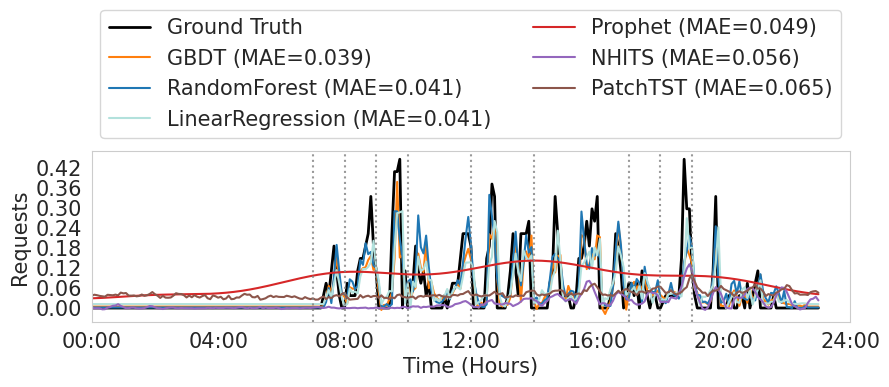

In [24]:
# ============================================================
# 📊 NORMALIZED PLOT FOR ALL MODELS (WITH CUSTOM VLINES + XTICKS)
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MaxNLocator

sns.set_style("whitegrid")
plt.figure(figsize=(9, 4))

palette = sns.color_palette("tab10")


model_info = {
    'GBDT':           {'color':palette[1], 'MAE': 0.039261},
    'RandomForest':   {'color':palette[0], 'MAE': 0.040640},
    'LinearRegression': {'color':"#B2E1DC", 'MAE': 0.041352},
    'Prophet':        {'color':palette[3],     'MAE': 0.049394},
    'NHITS':          {'color':palette[4],      'MAE': 0.055602},
    'PatchTST':       {'color':palette[5],      'MAE': 0.065310},
}

# --------------------------
# 1. NORMALIZED ground truth
# --------------------------
test_norm = scaler.transform(test.values).ravel()
test_norm_series = pd.Series(test_norm, index=test.index)
test_norm_filtered = test_norm_series.loc[start_date:end_date]

plt.plot(
    test_norm_filtered.index,
    test_norm_filtered.values,
    label="Ground Truth",
    color="black",
    linewidth=2
)

# --------------------------
# Helper to plot sklearn models (normalized)
# --------------------------
def plot_sklearn_model_normalized(model, label):
    preds_norm = model.predict(X_test)  # already 0–1
    preds_norm = preds_norm[-len(test):]  # align with test length
    preds_series = pd.Series(preds_norm, index=test.index).loc[start_date:end_date]

    plt.plot(
        preds_series.index,
        preds_series.values,
        label=f"{label} (MAE={model_info[label]['MAE']:.3f})",
        color=model_colors[label],
        linewidth=1.5
    )

# --------------------------
# 2. Classical Models
# --------------------------
gbdt = GradientBoostingRegressor(random_state=42)
gbdt.fit(X_train, y_train.ravel())
plot_sklearn_model_normalized(gbdt, "GBDT")

rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train.ravel())
plot_sklearn_model_normalized(rf, "RandomForest")

linr = LinearRegression()
linr.fit(X_train, y_train.ravel())
plot_sklearn_model_normalized(linr, "LinearRegression")

# --------------------------
# 3. Prophet (normalized)
# --------------------------
full_prophet = pd.concat([train, val])
full_prophet_df = full_prophet.reset_index().rename(
    columns={full_prophet.columns[0]: "y", "datetime": "ds"}
)
prophet_model = Prophet(stan_backend="CMDSTANPY")
prophet_model.fit(full_prophet_df)

future = test.reset_index().rename(columns={test.columns[0]: "y", "datetime": "ds"})
forecast = prophet_model.predict(future)

forecast_norm = scaler.transform(forecast["yhat"].values.reshape(-1,1)).ravel()
forecast_norm_series = pd.Series(forecast_norm, index=test.index).loc[start_date:end_date]

plt.plot(
    forecast_norm_series.index,
    forecast_norm_series.values,
    label=f"Prophet (MAE={model_info['Prophet']['MAE']:.3f})",
    color=model_colors["Prophet"],
    linewidth=1.5
)

# --------------------------
# 4. NeuralForecast models
# --------------------------
for model in models:
    name = model.__class__.__name__

    model_instance = model.__class__(input_size=lags, h=len(test), max_steps=300)
    nf = NeuralForecast(models=[model_instance], freq="5min")
    nf.fit(df=df_nf.iloc[:n_train + n_val])

    forecasts = nf.predict()
    forecast_col = [c for c in forecasts.columns if c not in ["unique_id","ds"]][0]

    pred = forecasts.query("unique_id == 'series_1'")[forecast_col].values

    pred_norm = scaler.transform(pred.reshape(-1,1)).ravel()
    pred_norm_series = pd.Series(pred_norm, index=test.index[-len(pred_norm):]).loc[start_date:end_date]

    plt.plot(
        pred_norm_series.index,
        pred_norm_series.values,
        label=f"{name} (MAE={model_info[name]['MAE']:.3f})",
        color=model_colors[name],
        linewidth=1.5
    )

# ============================================================
# FINAL PLOT STYLE (YOUR SETTINGS)
# ============================================================

plt.ylabel("Requests", fontsize=15)
# plt.ylim(0,1)

# --------------------------
# LEGEND
# --------------------------
plt.legend(
    loc='lower center',
    bbox_to_anchor=(0.5, 1.02),
    ncol=2,
    fontsize=15
)

# --------------------------
# CUSTOM XTICKS + VERTICAL LINES (YOUR EXACT LOGIC)
# --------------------------
ax = plt.gca()

base_ts = pd.to_datetime(start_date)

# Vertical dotted lines
line_hours = [7, 8, 9, 10, 12, 14, 17, 18, 19]
for h in line_hours:
    line_time = base_ts + pd.Timedelta(hours=h)
    plt.axvline(
        x=line_time,
        color='grey',
        linestyle=':',
        linewidth=1.5,
        alpha=0.8
    )

# X ticks every 4 hours from 00 to 24
target_hours = list(range(0, 25, 4))
tick_locs = [base_ts + pd.Timedelta(hours=h) for h in target_hours]
tick_labels = [f"{h:02d}:00" for h in target_hours]

ax.set_xticks(tick_locs)
ax.set_xticklabels(tick_labels)
ax.set_xlim(tick_locs[0], tick_locs[-1])
# ax.set_yticks([0, 0.5, 1])

ax.yaxis.set_major_locator(MaxNLocator(integer=True))
ax.set_xlabel("Time (Hours)", fontsize=15)

ax.tick_params(axis='x', labelsize=15)
ax.tick_params(axis='y', labelsize=15)

plt.grid(False)
plt.tight_layout()
plt.savefig("timeseries_benchmark_normalized_plot.pdf", dpi=200)
plt.show()


09:57:30 - cmdstanpy - INFO - Chain [1] start processing
09:57:30 - cmdstanpy - INFO - Chain [1] done processing
Seed set to 1
Seed set to 1
Seed set to 1
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name         | Type          | Params | Mode 
-------------------------------------------------------
0 | loss         | MAE           | 0      | train
1 | padder_train | ConstantPad1d | 0      | train
2 | scaler       | TemporalNorm  | 0      | train
3 | blocks       | ModuleList    | 3.4 M  | train
-------------------------------------------------------
3.4 M     Trainable params
0         Non-trainable params
3.4 M     Total params
13.722    Total estimated model params size (MB)


Epoch 99: 100%|██████████| 1/1 [00:00<00:00, 111.36it/s, v_num=696, train_loss_step=1.310, train_loss_epoch=1.310]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 199: 100%|██████████| 1/1 [00:00<00:00, 108.95it/s, v_num=696, train_loss_step=1.300, train_loss_epoch=1.290]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 299: 100%|██████████| 1/1 [00:00<00:00, 111.62it/s, v_num=696, train_loss_step=1.280, train_loss_epoch=1.270]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 299: 100%|██████████| 1/1 [00:00<00:00, 61.25it/s, v_num=696, train_loss_step=1.280, train_loss_epoch=1.280] 

`Trainer.fit` stopped: `max_steps=300` reached.


Epoch 299: 100%|██████████| 1/1 [00:00<00:00, 56.14it/s, v_num=696, train_loss_step=1.280, train_loss_epoch=1.280]


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


...

Epoch 99: 100%|██████████| 1/1 [00:00<00:00, 101.92it/s, v_num=698, train_loss_step=1.810, train_loss_epoch=1.800]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 199: 100%|██████████| 1/1 [00:00<00:00, 98.00it/s, v_num=698, train_loss_step=1.560, train_loss_epoch=1.560] 
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 299: 100%|██████████| 1/1 [00:00<00:00, 102.10it/s, v_num=698, train_loss_step=1.480, train_loss_epoch=1.490]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 299: 100%|██████████| 1/1 [00:00<00:00, 60.41it/s, v_num=698, train_loss_step=1.480, train_loss_epoch=1.480] 

`Trainer.fit` stopped: `max_steps=300` reached.


Epoch 299: 100%|██████████| 1/1 [00:00<00:00, 55.89it/s, v_num=698, train_loss_step=1.480, train_loss_epoch=1.480]


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 291.07it/s]


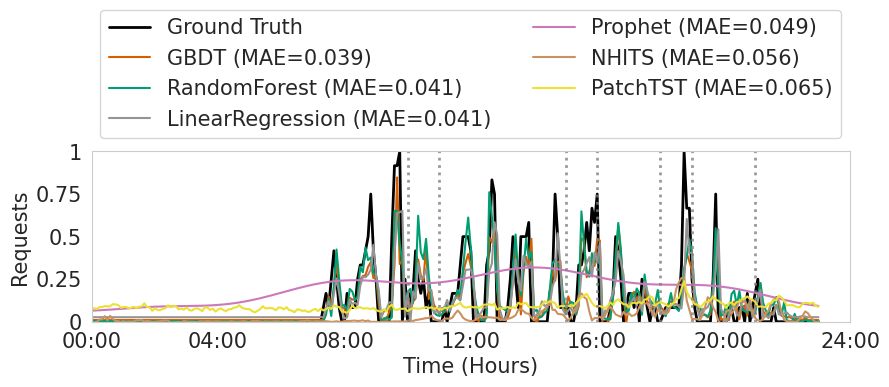

In [6]:
# ======================================================
# 📘 Time Series Benchmarking (Normalized Window-Based Evaluation)
# Models: RF, GBDT, Linear, Prophet, N-HiTS, PatchTST
# ======================================================

import pandas as pd
import numpy as np
import time
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from prophet import Prophet
from neuralforecast import NeuralForecast
from neuralforecast.models.nhits import NHITS
from neuralforecast.models.patchtst import PatchTST

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
from matplotlib.ticker import MaxNLocator


# ======================================================
# --- Prepare Data ---
# ======================================================

if isinstance(ts_only, pd.Series):
    ts_only = ts_only.to_frame(name='value')

if not isinstance(ts_only.index, pd.DatetimeIndex):
    ts_only.index = pd.to_datetime(ts_only.index)

ts_only = ts_only.sort_index()
points_per_day = 24 * 60 // 5  # 288 samples/day

n_train = 7 * points_per_day
n_val   = 3 * points_per_day
n_test  = 4 * points_per_day

train = ts_only.iloc[:n_train]
val   = ts_only.iloc[n_train:n_train+n_val]
test  = ts_only.iloc[n_train+n_val:]


# ======================================================
# --- Fit MinMaxScaler ---
# ======================================================

scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train)
val_scaled   = scaler.transform(val)
test_scaled  = scaler.transform(test)


# ======================================================
# --- Lagged data for sklearn models ---
# ======================================================

def create_lagged_features(data, lags=12):
    X, y = [], []
    for i in range(lags, len(data)):
        X.append(data[i-lags:i])
        y.append(data[i])
    return np.array(X), np.array(y)

lags = 12
X_train, y_train = create_lagged_features(train_scaled)
X_val, y_val = create_lagged_features(np.concatenate([train_scaled[-lags:], val_scaled]))
X_test, y_test = create_lagged_features(np.concatenate([train_scaled[-lags:], val_scaled, test_scaled]))

X_train = X_train.reshape(X_train.shape[0], -1)
X_val   = X_val.reshape(X_val.shape[0], -1)
X_test  = X_test.reshape(X_test.shape[0], -1)

results = {}


# ======================================================
# --- Evaluation Function ---
# ======================================================

def evaluate_model(name, model, X_train, y_train, scaler):
    start_train = time.time()
    model.fit(X_train, y_train.ravel())
    train_time = time.time() - start_train

    start_infer = time.time()
    preds_val = model.predict(X_val)
    preds_test = model.predict(X_test)
    infer_time = time.time() - start_infer

    # inverse-scale predictions for plotting
    preds_val_inv = scaler.inverse_transform(preds_val.reshape(-1,1)).ravel()
    preds_test_inv = scaler.inverse_transform(preds_test.reshape(-1,1)).ravel()

    return preds_test_inv, preds_val_inv, train_time, infer_time, model


# ======================================================
# --- Train Classic Models ---
# ======================================================

rf_pred_test_inv, rf_pred_val_inv, rf_train_t, rf_inf_t, rf_model = evaluate_model(
    "RF", RandomForestRegressor(n_estimators=200, random_state=42),
    X_train, y_train, scaler
)

gbdt_pred_test_inv, gbdt_pred_val_inv, gbdt_train_t, gbdt_inf_t, gbdt_model = evaluate_model(
    "GBDT", GradientBoostingRegressor(random_state=42),
    X_train, y_train, scaler
)

lr_pred_test_inv, lr_pred_val_inv, lr_train_t, lr_inf_t, lr_model = evaluate_model(
    "LR", LinearRegression(),
    X_train, y_train, scaler
)


# ======================================================
# --- Prophet ---
# ======================================================

full_prophet_df = pd.concat([train, val])
full_prophet_df = full_prophet_df.reset_index().rename(columns={'datetime':'ds', 'value':'y'})

prophet_model_full = Prophet(stan_backend="CMDSTANPY")
prophet_model_full.fit(full_prophet_df)

future = test.reset_index().rename(columns={'datetime':'ds', 'value':'y'})
forecast_test = prophet_model_full.predict(future)
prophet_pred_test = forecast_test['yhat'].values


# ======================================================
# --- NeuralForecast Models ---
# ======================================================

df_nf = ts_only.reset_index().rename(columns={'datetime':'ds','value':'y'})
df_nf['unique_id'] = 'series_1'

nf_train_end = n_train + n_val

models = [
    NHITS(input_size=lags, h=n_test, max_steps=300),
    PatchTST(input_size=lags, h=n_test, max_steps=300)
]

nf_preds = {}

for model in models:
    name = model.__class__.__name__
    m = model.__class__(input_size=lags, h=n_test, max_steps=300)

    nf = NeuralForecast(models=[m], freq="5min")
    nf.fit(df=df_nf.iloc[:nf_train_end])

    forecasts = nf.predict()
    col = [c for c in forecasts.columns if c not in ['unique_id','ds']][0]

    series_pred = forecasts.query("unique_id=='series_1'")[col].values
    nf_preds[name] = series_pred


# ======================================================
# --- Select Window for Evaluation ---
# ======================================================

start_date = "1970-01-13 05:00"
end_date   = "1970-01-14 04:00"

test_window = test.loc[start_date:end_date]
max_val_window = test_window['value'].max()

def normalize(series):
    return series / max_val_window


# ======================================================
# --- Normalize predictions inside window ---
# ======================================================

# align using pandas indexing
def align_and_normalize(pred_array):
    pred_series = pd.Series(pred_array[-len(test):], index=test.index)
    pred_window = pred_series.loc[start_date:end_date]
    return normalize(pred_window), pred_window


# Ground truth
gt_norm = normalize(test_window['value'])


# Classic models
rf_norm, rf_true = align_and_normalize(rf_pred_test_inv)
gbdt_norm, gbdt_true = align_and_normalize(gbdt_pred_test_inv)
lr_norm, lr_true = align_and_normalize(lr_pred_test_inv)

# Prophet
prophet_norm, prophet_true = align_and_normalize(prophet_pred_test)

# NeuralForecast
n_hits_norm, n_hits_true = align_and_normalize(nf_preds["NHITS"])
patchtst_norm, patchtst_true = align_and_normalize(nf_preds["PatchTST"])


# ======================================================
# --- Compute Normalized MAE ---
# ======================================================
palette = sns.color_palette("colorblind")

model_info = {
    "GBDT":  {"color":palette[3], "MAE": 0.039261},
    "RandomForest": {"color":palette[2], "MAE": 0.040640},
    "LinearRegression": {"color":palette[7], "MAE": 0.041352},
    "Prophet": {"color":palette[4], "MAE": 0.049394},
    "NHITS": {"color":palette[5], "MAE": 0.055602},
    "PatchTST": {"color":palette[8], "MAE": 0.065310},
}

# ======================================================
# --- Plot Normalized Window ---
# ======================================================

plt.figure(figsize=(9,4))
sns.set_style("whitegrid")

# Ground truth
plt.plot(gt_norm.index, gt_norm.values, color="black", linewidth=2, label="Ground Truth")

# Plot each model
plt.plot(gbdt_norm.index, gbdt_norm.values, color=model_info["GBDT"]["color"],
         label=f"GBDT (MAE={model_info['GBDT']['MAE']:.3f})")
plt.plot(rf_norm.index, rf_norm.values, color=model_info["RandomForest"]["color"],
         label=f"RandomForest (MAE={model_info['RandomForest']['MAE']:.3f})")
plt.plot(lr_norm.index, lr_norm.values, color=model_info["LinearRegression"]["color"],
         label=f"LinearRegression (MAE={model_info['LinearRegression']['MAE']:.3f})")
plt.plot(prophet_norm.index, prophet_norm.values, color=model_info["Prophet"]["color"],
         label=f"Prophet (MAE={model_info['Prophet']['MAE']:.3f})")
plt.plot(n_hits_norm.index, n_hits_norm.values, color=model_info["NHITS"]["color"],
         label=f"NHITS (MAE={model_info['NHITS']['MAE']:.3f})")
plt.plot(patchtst_norm.index, patchtst_norm.values, color=model_info["PatchTST"]["color"],
         label=f"PatchTST (MAE={model_info['PatchTST']['MAE']:.3f})")


# ======================================================
# --- Custom X-axis Ticks & Vertical Lines ---
# ======================================================

ax = plt.gca()
base_ts = pd.to_datetime(start_date)

# line_hours = [7, 8, 9, 10, 12, 14, 17, 18, 19]
line_hours = [10, 11, 15, 16, 18, 19, 21]
for h in line_hours:
    plt.axvline(x=base_ts + pd.Timedelta(hours=h), color="grey",
                linestyle=":", linewidth=2, alpha=0.8)

target_hours = list(range(0, 25, 4))
tick_locs = [base_ts + pd.Timedelta(hours=h) for h in target_hours]
tick_labels = [f"{h:02d}:00" for h in target_hours]

ax.set_xticks(tick_locs)
ax.set_xticklabels(tick_labels, fontsize=15)
ax.set_xlim(tick_locs[0], tick_locs[-1])
yticks = [0, 0.25, 0.5, 0.75, 1]
ytick_labels = ["0", "0.25", "0.5", "0.75", "1"]

ax.set_yticks(yticks)
ax.set_yticklabels(ytick_labels, fontsize=15)
ax.set_ylim(0, 1)
# ax.set_yticklabels([0, 0.5, 1.0])
ax.set_xlabel("Time (Hours)", fontsize=15)
ax.set_ylabel("Requests", fontsize=15)
# ax.yaxis.set_major_locator(MaxNLocator(nbins=5))

plt.legend(loc="lower center", bbox_to_anchor=(0.5, 1.02),
           ncol=2, fontsize=15)

plt.grid(False)
plt.tight_layout()
plt.savefig("timeseries_benchmark_normalized_window_plot.pdf", dpi=200)
plt.show()


## bucketized prediction

In [6]:
rf_df = pd.DataFrame({
    "datetime": val.index[:len(rf_y_true_inv)],
    "true": rf_y_true_inv,
    "pred": rf_y_pred_inv
}).reset_index(drop=True)

# --------------------------
# 1️⃣ Create bucket edges
# --------------------------
num_buckets = 4

vmin = rf_df["true"].min()
vmax = rf_df["true"].max()

bucket_edges = np.linspace(vmin, vmax, num_buckets + 1)

print("\nBucket Edges:")
for i in range(len(bucket_edges) - 1):
    print(f"Bucket {i+1}: {bucket_edges[i]:.4f} → {bucket_edges[i+1]:.4f}")

# --------------------------
# 2️⃣ Assign bucket IDs
# --------------------------
rf_df["bucket_true"] = pd.cut(
    rf_df["true"],
    bins=bucket_edges,
    labels=range(1, num_buckets + 1),
    include_lowest=True
).astype(int)

rf_df["bucket_pred"] = pd.cut(
    rf_df["pred"],
    bins=bucket_edges,
    labels=range(1, num_buckets + 1),
    include_lowest=True
).astype(int)



bucket_output = rf_df[["datetime", "bucket_true", "bucket_pred"]]
bucket_output.to_csv("rf_bucket_predictions.csv", index=False)

print("Saved rf_bucket_predictions.csv")



Bucket Edges:
Bucket 1: 0.0000 → 5.5000
Bucket 2: 5.5000 → 11.0000
Bucket 3: 11.0000 → 16.5000
Bucket 4: 16.5000 → 22.0000
Saved rf_bucket_predictions.csv


## Error for models

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load your results
results_df = pd.read_csv("timeseries_benchmark_results.csv", index_col=0)

# --- Plot settings ---
plt.figure(figsize=(12, 10))

# 1️⃣ MAE
plt.subplot(3, 1, 1)
plt.bar(results_df.index, results_df["MAE"], color="skyblue")
plt.title("Model Comparison: MAE")
plt.ylabel("MAE")
plt.yscale('log')
plt.grid(axis='y', linestyle='--', alpha=0.6)

# 2️⃣ Training Time
plt.subplot(3, 1, 2)
plt.bar(results_df.index, results_df["train_time"], color="lightgreen")
plt.title("Model Training Time")
plt.ylabel("Seconds")
plt.yscale('log')
plt.grid(axis='y', linestyle='--', alpha=0.6)

# 3️⃣ Inference Time
plt.subplot(3, 1, 3)
plt.bar(results_df.index, results_df["infer_time"], color="salmon")
plt.title("Model Inference Time")
plt.ylabel("Seconds")
plt.yscale('log')
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


## Plot pred vs true

17:55:00 - cmdstanpy - INFO - Chain [1] start processing
17:55:00 - cmdstanpy - INFO - Chain [1] done processing
Seed set to 1
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name         | Type          | Params | Mode 
-------------------------------------------------------
0 | loss         | MAE           | 0      | train
1 | padder_train | ConstantPad1d | 0      | train
2 | scaler       | TemporalNorm  | 0      | train
3 | blocks       | ModuleList    | 3.4 M  | train
-------------------------------------------------------
3.4 M     Trainable params
0         Non-trainable params
3.4 M     Total params
13.709    Total estimated model params size (MB)


Epoch 99: 100%|██████████| 1/1 [00:00<00:00, 109.52it/s, v_num=544, train_loss_step=1.320, train_loss_epoch=1.310]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 199: 100%|██████████| 1/1 [00:00<00:00, 112.03it/s, v_num=544, train_loss_step=1.290, train_loss_epoch=1.290]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 299: 100%|██████████| 1/1 [00:00<00:00, 110.45it/s, v_num=544, train_loss_step=1.280, train_loss_epoch=1.270]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 299: 100%|██████████| 1/1 [00:00<00:00, 59.88it/s, v_num=544, train_loss_step=1.280, train_loss_epoch=1.280] 

`Trainer.fit` stopped: `max_steps=300` reached.


Epoch 299: 100%|██████████| 1/1 [00:00<00:00, 55.08it/s, v_num=544, train_loss_step=1.280, train_loss_epoch=1.280]


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


...

Epoch 99: 100%|██████████| 1/1 [00:00<00:00, 100.43it/s, v_num=546, train_loss_step=1.820, train_loss_epoch=1.800]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 199: 100%|██████████| 1/1 [00:00<00:00, 101.18it/s, v_num=546, train_loss_step=1.560, train_loss_epoch=1.570]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 299: 100%|██████████| 1/1 [00:00<00:00, 100.32it/s, v_num=546, train_loss_step=1.480, train_loss_epoch=1.490]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 299: 100%|██████████| 1/1 [00:00<00:00, 56.79it/s, v_num=546, train_loss_step=1.480, train_loss_epoch=1.480] 

`Trainer.fit` stopped: `max_steps=300` reached.


Epoch 299: 100%|██████████| 1/1 [00:00<00:00, 52.73it/s, v_num=546, train_loss_step=1.480, train_loss_epoch=1.480]


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 250.51it/s]


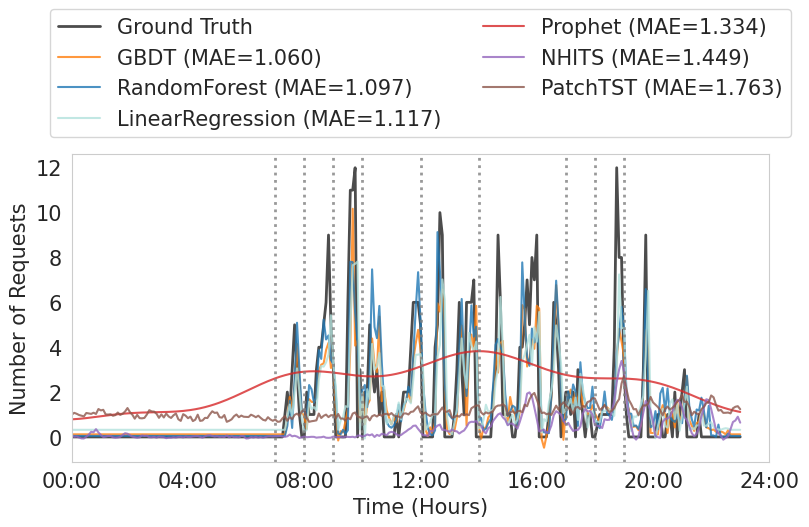

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from prophet import Prophet
from neuralforecast import NeuralForecast
import matplotlib.dates as mdates
from matplotlib.ticker import MaxNLocator


# --------------------------
# Seaborn color palettes
# --------------------------
plt.figure(figsize=(9, 4))
sns.set_style("whitegrid")

palette = sns.color_palette("tab10")

gt_color = "black"

# Mapping models to seaborn colors and MAE
model_info = {
    'GBDT':           {'color':palette[1], 'MAE': 1.060037},
    'RandomForest':   {'color':palette[0], 'MAE': 1.097289},
    'LinearRegression': {'color':"#B2E1DC", 'MAE': 1.116506},
    'Prophet':        {'color':palette[3],     'MAE': 1.333645},
    'NHITS':          {'color':palette[4],      'MAE': 1.448774},
    'PatchTST':       {'color':palette[5],      'MAE': 1.763380},
}

# --- Filter time range ---
start_date = '1970-01-13 05:00'
end_date   = '1970-01-14 04:00'

test_filtered = test.loc[start_date:end_date]

# --- Plot true test data ---
plt.plot(test_filtered.index, test_filtered['value'], label='Ground Truth', color='black', linewidth=2, alpha=0.7)

# Helper function to plot sklearn models
def plot_sklearn_model(model, X_test, scaler, label):
    preds = model.predict(X_test)
    preds = scaler.inverse_transform(preds.reshape(-1,1)).ravel()
    preds = preds[-len(test):]  # align with full test
    # Filter to time range
    preds_filtered = pd.Series(preds, index=test.index).loc[start_date:end_date]
    plt.plot(preds_filtered.index, preds_filtered.values,
             label=f"{label} (MAE={model_info[label]['MAE']:.3f})",
             color=model_info[label]['color'], linewidth=1.5, alpha=0.8)

# --- Classical models ---

gbdt_model = GradientBoostingRegressor(random_state=42)
gbdt_model.fit(X_train, y_train.ravel())
# plot_sklearn_model(gbdt_model, X_test, scaler, 'GBDT')
gdbt_preds_scaled = gbdt_model.predict(X_test)
gdbt_preds = scaler.inverse_transform(gdbt_preds_scaled.reshape(-1,1)).ravel()
gdbt_preds = gdbt_preds[-len(test):]  # align with test

# Plot
plot_sklearn_model(gbdt_model, X_test, scaler, 'GBDT')




rf_model = RandomForestRegressor(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train.ravel())
plot_sklearn_model(rf_model, X_test, scaler, 'RandomForest')



linr_model = LinearRegression()
linr_model.fit(X_train, y_train.ravel())
plot_sklearn_model(linr_model, X_test, scaler, 'LinearRegression')

# --- Prophet ---
full_prophet = pd.concat([train, val])
full_prophet_df = full_prophet.reset_index().rename(columns={full_prophet.columns[0]: 'y', 'datetime': 'ds'})
prophet_model_full = Prophet(stan_backend='CMDSTANPY')
prophet_model_full.fit(full_prophet_df)

future = test.reset_index().rename(columns={test.columns[0]: 'y', 'datetime': 'ds'})
forecast_test = prophet_model_full.predict(future)
forecast_filtered = forecast_test.set_index('ds').loc[start_date:end_date]
plt.plot(forecast_filtered.index, forecast_filtered['yhat'],
         label=f"Prophet (MAE={model_info['Prophet']['MAE']:.3f})",
         color=model_info['Prophet']['color'], linewidth=1.5, alpha=0.8)

# --- NeuralForecast models ---
for model in models:
    name = model.__class__.__name__
    model_instance = model.__class__(input_size=lags, h=len(test), max_steps=300)
    nf = NeuralForecast(models=[model_instance], freq='5min')
    nf.fit(df=df_nf.iloc[:n_train + n_val])
    forecasts = nf.predict()
    forecast_col = [c for c in forecasts.columns if c not in ['unique_id','ds']][0]
    y_pred = forecasts.query("unique_id == 'series_1'")[forecast_col].values
    y_pred_series = pd.Series(y_pred, index=test.index[-len(y_pred):]).loc[start_date:end_date]
    plt.plot(y_pred_series.index, y_pred_series.values,
             label=f"{name} (MAE={model_info[name]['MAE']:.3f})",
             color=model_info[name]['color'], linewidth=1.5, alpha=0.8)

# # --- Final plot settings ---
# plt.ylabel("Number of Requests", fontsize=15)
# plt.legend(
#     loc='lower center',        # attach bottom of legend
#     bbox_to_anchor=(0.5, 1.02),# a point centered above the axes
#     ncol=2,                    # optional: spread items in 3 columns
#     fontsize=15
# )

# start_ts = pd.to_datetime(test_filtered.index[0])

# ax = plt.gca()
# xticks = ax.get_xticks()

# tick_labels = []
# for xt in xticks:
#     # convert matplotlib float → datetime, remove timezone
#     dt = mdates.num2date(xt).replace(tzinfo=None)

#     # compute hours since start
#     hours = int((dt - start_ts).total_seconds() / 3600)
#     tick_labels.append(str(hours))

# ax.yaxis.set_major_locator(MaxNLocator(integer=True))
# ax.set_xticks(xticks)
# ax.set_xticklabels(tick_labels)
# ax.set_xlabel("Time (Hours)", fontsize=15)
# # Tick label font sizes
# ax.tick_params(axis='x', labelsize=15)
# ax.tick_params(axis='y', labelsize=15)

# plt.grid(False)
# # plt.tight_layout()
# # plt.subplots_adjust(left=0.18, right=0.72, top=0.72, bottom=0.18)
# plt.savefig("model_predictions_zoomed_new.pdf", bbox_inches='tight')
# plt.show()

# --- Final plot settings ---
plt.ylabel("Number of Requests", fontsize=15)
plt.legend(
    loc='lower center',
    bbox_to_anchor=(0.5, 1.02),
    ncol=2,
    fontsize=15
)

# ---------------------------------------------------------
# NEW LOGIC: Manually set ticks for 00, 04, ... 24 hours
# ---------------------------------------------------------
ax = plt.gca()

# 1. Convert your start_date string to a datetime object
base_ts = pd.to_datetime(start_date)

line_hours = [7, 8, 9, 10, 12, 14, 17, 18, 19] 

for h in line_hours:
    # Calculate the exact time for the line
    line_time = base_ts + pd.Timedelta(hours=h)
    
    # Plot the vertical line
    plt.axvline(x=line_time, color='grey', linestyle=':', linewidth=2, alpha=0.8)


# 2. Define the specific hour offsets you want: 0, 4, 8, 12, 16, 20, 24
target_hours = list(range(0, 25, 4)) 

# 3. Calculate the actual datetime location for each tick
tick_locs = [base_ts + pd.Timedelta(hours=h) for h in target_hours]

# 4. Create the labels formatted with leading zeros ("00", "04", etc.)
tick_labels = [f"{h:02d}:00" for h in target_hours]

# 5. Apply ticks and labels to the axis
ax.set_xticks(tick_locs)
ax.set_xticklabels(tick_labels)

# 6. (Optional) Force the graph limits to match exactly 0h to 24h 
# so the '00' and '24' align with the edges
ax.set_xlim(tick_locs[0], tick_locs[-1])
# ---------------------------------------------------------

ax.yaxis.set_major_locator(MaxNLocator(integer=True))
ax.set_xlabel("Time (Hours)", fontsize=15)

# Tick label font sizes
ax.tick_params(axis='x', labelsize=15)
ax.tick_params(axis='y', labelsize=15)

plt.grid(False)
plt.savefig("model_predictions_zoomed_new.pdf", bbox_inches='tight')
plt.show()

In [16]:
# ============================================================
#  📦 BUCKETIZE RF TEST PREDICTIONS (Last 4 days)
# ============================================================

# Test true values (already scaled → inverse in your pipeline earlier)
test_true = test['value'].values

# Align predictions (ensure same length)
gdbt_preds = gdbt_preds[-len(test_true):]

# Build DataFrame
gdbt_bucket_df = pd.DataFrame({
    "datetime": test.index,
    "true": test_true,
    "pred": gdbt_preds
})

# --------------------------
# 1️⃣ Create bucket edges from test TRUE values
# --------------------------
num_buckets = 4
vmin = gdbt_bucket_df["true"].min()
vmax = gdbt_bucket_df["true"].max()
bucket_edges = np.linspace(vmin, vmax, num_buckets + 1)

# --------------------------
# 2️⃣ Assign bucket IDs
# --------------------------
gdbt_bucket_df["bucket_true"] = pd.cut(
    gdbt_bucket_df["true"],
    bins=bucket_edges,
    labels=range(1, num_buckets + 1),
    include_lowest=True
).fillna(1).astype(int)  # Assign to bucket 1 if NaN

gdbt_bucket_df["bucket_pred"] = pd.cut(
    gdbt_bucket_df["pred"],
    bins=bucket_edges,
    labels=range(1, num_buckets + 1),
    include_lowest=True
).fillna(1).astype(int)  # Assign to bucket 1 if NaN

# --------------------------
# 3️⃣ Save only the required 3 columns
# --------------------------
bucket_csv = gdbt_bucket_df[["datetime", "bucket_true", "bucket_pred"]]
bucket_csv.to_csv("gdbt_test_bucket_predictions.csv", index=False)

print("Saved gdbt_test_bucket_predictions.csv")


Saved gdbt_test_bucket_predictions.csv
